# File: 01_dataset_validation.ipynb

## Purpose
This notebook validates the cleaned satellite dataset by checking missing values, data consistency, data types, and ensuring the dataset is ready for analysis.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
df = pd.read_csv("../data/raw/current_catalog.csv")

In [68]:
df1=df.copy()

In [69]:
print("Shape:", df.shape)
df1.head()

Shape: (16649, 19)


,norad_id,name,object_type,satellite_constellation,altitude_km,altitude_category,orbital_band,congestion_risk,inclination,eccentricity,launch_year_estimate,days_in_orbit_estimate,orbit_lifetime_category,mean_motion,epoch,data_source,snapshot_date,country,last_seen
0,900,CALSPHERE 1,PAYLOAD,Other,975.794787,Low LEO,LEO-Polar,LOW,90.2213,0.002375,2024,0,<1yr,13.766495,2026-07-13 03:15:37.038240,celestrak,2026-07-13,US,2026-07-13
1,902,CALSPHERE 2,PAYLOAD,Other,1061.599445,Mid LEO,LEO-Polar,LOW,90.2347,0.001955,2024,0,<1yr,13.529023,2026-07-13 03:50:06.194688,celestrak,2026-07-13,US,2026-07-13
2,1361,LCS 1,PAYLOAD,Other,2787.866858,High LEO,MEO,LOW,32.1398,0.001237,2024,0,<1yr,9.893107,2026-07-13 05:22:30.480096,celestrak,2026-07-13,US,2026-07-13
3,1512,TEMPSAT 1,PAYLOAD,Other,1133.231902,Mid LEO,LEO-Polar,HIGH,89.9978,0.006993,2024,0,<1yr,13.335955,2026-07-13 11:40:59.394720,celestrak,2026-07-13,US,2026-07-13
4,1520,CALSPHERE 4A,PAYLOAD,Other,1123.157652,Mid LEO,LEO-Polar,HIGH,89.8990,0.007140,2024,0,<1yr,13.362829,2026-07-13 12:07:15.869856,celestrak,2026-07-13,US,2026-07-13


In [70]:
df1.isnull().sum()

norad_id                   0
name                       0
object_type                2
satellite_constellation    0
altitude_km                0
altitude_category          0
orbital_band               0
congestion_risk            0
inclination                0
eccentricity               0
launch_year_estimate       0
days_in_orbit_estimate     0
orbit_lifetime_category    0
mean_motion                0
epoch                      0
data_source                0
snapshot_date              0
country                    2
last_seen                  0
dtype: int64

In [71]:
df1.duplicated().sum()

np.int64(0)

In [72]:
df1["norad_id"].duplicated().sum()

np.int64(0)

In [73]:
df1.describe()

,norad_id,altitude_km,inclination,eccentricity,launch_year_estimate,days_in_orbit_estimate,mean_motion
count,16649.000000,16649.000000,16649.000000,16649.000000,16649.000000,16649.000000,16649.000000
mean,58320.337558,2128.445599,61.575360,0.002705,2023.993153,0.233347,14.431601
std,9002.237634,7393.585752,24.241234,0.039241,0.082467,1.164107,3.079388
min,900.000000,134.803799,0.001600,0.000003,2023.000000,-2.000000,0.073149
25%,53425.000000,462.759309,43.004300,0.000117,2024.000000,0.000000,15.027965
50%,59885.000000,483.036795,53.159500,0.000166,2024.000000,0.000000,15.275841
75%,65435.000000,558.277839,87.907100,0.000324,2024.000000,0.000000,15.343811
max,69973.000000,235127.946482,150.047500,0.908760,2024.000000,29.000000,16.517224


In [74]:
df1.dtypes

norad_id                     int64
name                        object
object_type                 object
satellite_constellation     object
altitude_km                float64
altitude_category           object
orbital_band                object
congestion_risk             object
inclination                float64
eccentricity               float64
launch_year_estimate         int64
days_in_orbit_estimate       int64
orbit_lifetime_category     object
mean_motion                float64
epoch                       object
data_source                 object
snapshot_date               object
country                     object
last_seen                   object
dtype: object

In [75]:
df1["object_type"].value_counts()

object_type
PAYLOAD        16011
UNKNOWN          622
ROCKET BODY       13
DEBRIS             1
Name: count, dtype: int64

In [76]:
df1["country"].value_counts()

country
US      12541
PRC      1475
UK        701
CIS       295
TBD       280
        ...  
BELA        1
LAOS        1
TMMC        1
FRIT        1
ROM         1
Name: count, Length: 95, dtype: int64

In [77]:
(df1["mean_motion"] <= 0).sum()

np.int64(0)

In [78]:
(df1["eccentricity"] < 0).sum()

np.int64(0)

In [79]:
(df1["eccentricity"] > 1).sum()

np.int64(0)

In [80]:
df1.corr(numeric_only=True)

,norad_id,altitude_km,inclination,eccentricity,launch_year_estimate,days_in_orbit_estimate,mean_motion
norad_id,1.000000,-0.379610,0.127161,-0.070471,0.043748,-0.023984,0.419597
altitude_km,-0.379610,1.000000,-0.422381,0.263532,0.016750,0.122909,-0.934953
inclination,0.127161,-0.422381,1.000000,-0.009428,-0.016428,-0.000707,0.379299
eccentricity,-0.070471,0.263532,-0.009428,1.000000,-0.010013,0.187960,-0.233363
launch_year_estimate,0.043748,0.016750,-0.016428,-0.010013,1.000000,-0.050305,-0.042346
days_in_orbit_estimate,-0.023984,0.122909,-0.000707,0.187960,-0.050305,1.000000,-0.097917
mean_motion,0.419597,-0.934953,0.379299,-0.233363,-0.042346,-0.097917,1.000000


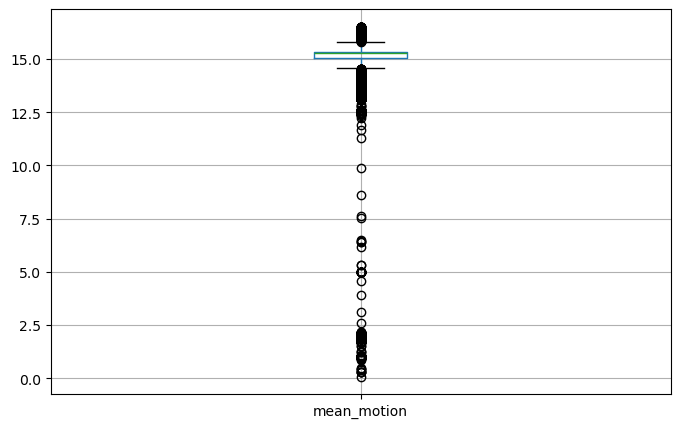

In [81]:
plt.figure(figsize=(8,5))
df1.boxplot(column="mean_motion")
plt.show()

In [82]:
print(df1.columns)

Index(['norad_id', 'name', 'object_type', 'satellite_constellation',
       'altitude_km', 'altitude_category', 'orbital_band', 'congestion_risk',
       'inclination', 'eccentricity', 'launch_year_estimate',
       'days_in_orbit_estimate', 'orbit_lifetime_category', 'mean_motion',
       'epoch', 'data_source', 'snapshot_date', 'country', 'last_seen'],
      dtype='object')


In [83]:
(df1["altitude_km"] <= 0).sum()

np.int64(0)

In [84]:
df1["norad_id"].duplicated().sum()

np.int64(0)

In [85]:
df1.isnull().sum()

norad_id                   0
name                       0
object_type                2
satellite_constellation    0
altitude_km                0
altitude_category          0
orbital_band               0
congestion_risk            0
inclination                0
eccentricity               0
launch_year_estimate       0
days_in_orbit_estimate     0
orbit_lifetime_category    0
mean_motion                0
epoch                      0
data_source                0
snapshot_date              0
country                    2
last_seen                  0
dtype: int64

In [86]:
(df1["altitude_km"] <= 0).sum()

np.int64(0)

In [87]:
((df1["eccentricity"] < 0) | (df1["eccentricity"] > 1)).sum()

np.int64(0)

In [88]:
(df1["mean_motion"] <= 0).sum()

np.int64(0)

In [89]:
((df1["launch_year_estimate"] < 1957) | (df1["launch_year_estimate"] > 2035)).sum()

np.int64(0)

In [90]:
(df1["days_in_orbit_estimate"] < 0).sum()

np.int64(2)

In [91]:
df1["country"].value_counts().head(10)

country
US     12541
PRC     1475
UK       701
CIS      295
TBD      280
JPN      131
IT        87
FR        75
IND       74
ESA       70
Name: count, dtype: int64

In [92]:
df1["data_source"].value_counts()

data_source
celestrak    16649
Name: count, dtype: int64

In [93]:
df1["snapshot_date"].describe()

count          16649
unique           200
top       2026-07-13
freq           15985
Name: snapshot_date, dtype: object

In [94]:
df1.isnull().sum()

norad_id                   0
name                       0
object_type                2
satellite_constellation    0
altitude_km                0
altitude_category          0
orbital_band               0
congestion_risk            0
inclination                0
eccentricity               0
launch_year_estimate       0
days_in_orbit_estimate     0
orbit_lifetime_category    0
mean_motion                0
epoch                      0
data_source                0
snapshot_date              0
country                    2
last_seen                  0
dtype: int64

In [95]:
 df1[df1.isnull().any(axis=1)]

,norad_id,name,object_type,satellite_constellation,altitude_km,altitude_category,orbital_band,congestion_risk,inclination,eccentricity,launch_year_estimate,days_in_orbit_estimate,orbit_lifetime_category,mean_motion,epoch,data_source,snapshot_date,country,last_seen
15446,68538,ARTEMIS 2,NaN,Other,35114.009821,GEO,MEO,LOW,28.3222,0.843293,2024,-1,UNKNOWN,1.027197,2026-04-02 23:30:16.620192,celestrak,2026-04-02,NaN,2026-04-02
16648,69973,2026-158B,NaN,Other,808.878418,Low LEO,LEO-Inclined,MEDIUM,49.9848,0.000567,2024,0,<1yr,14.248853,2026-07-11 13:13:49.325376,celestrak,2026-07-11,NaN,2026-07-11


In [96]:
df1["object_type"] = df1["object_type"].fillna("UNKNOWN")
df1["country"] = df1["country"].fillna("UNKNOWN")

In [97]:
df1[["object_type", "country"]].isnull().sum()

object_type    0
country        0
dtype: int64

In [98]:
df1.isnull().sum()

norad_id                   0
name                       0
object_type                0
satellite_constellation    0
altitude_km                0
altitude_category          0
orbital_band               0
congestion_risk            0
inclination                0
eccentricity               0
launch_year_estimate       0
days_in_orbit_estimate     0
orbit_lifetime_category    0
mean_motion                0
epoch                      0
data_source                0
snapshot_date              0
country                    0
last_seen                  0
dtype: int64